In [2]:

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(
    style="whitegrid",
    font_scale=1.1
)

plt.rcParams.update({

    "figure.figsize": (20, 10),
    "figure.dpi": 110,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "grid.alpha": 1

})

In [3]:
   
def softmax(Z):
    exp = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp / np.sum(exp, axis=1, keepdims=True)
   
def aug(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

def loss(X, Y, theta):
    Z = aug(X) @ theta.T
    P = softmax(Z)
    return -np.mean(np.sum(Y * np.log(P), axis=1))

def grad(X, Y, theta):
    m = X.shape[0]
    P = softmax(aug(X) @ theta.T)
    return (P - Y).T @ aug(X) / m

def train(X, Y, epochs, lr):
    theta = np.zeros((Y.shape[1], X.shape[1] + 1 ))
    for _ in range(epochs):
        theta -= lr * grad(X, Y, theta)
    return theta

def predict(X, theta):
    X_aug = aug(X)                    # (m, f)
    Z = X_aug @ theta.T               # (m, k)
    P = softmax(Z)                    # (m, k)
    return np.argmax(P, axis=1)       # (m,)

def predict_proba(X , theta ):
    return softmax(aug(X) @ theta)

   

In [4]:
from sklearn import datasets
iris = datasets.load_iris()
X ,y = iris["data"][:,2:] , iris["target"]
x_petal_length , x_petal_width = X[:, 0] , X[: , 1] 

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import  precision_score , recall_score, confusion_matrix
ohe = OneHotEncoder(sparse_output= False)
Y = ohe.fit_transform(y.reshape((-1,1)))
theta = train( X , Y , 1000 , 0.05)
y_pred = predict(X ,theta)
precision_score(y_pred , y , average="macro")
recall_score(y_pred , y , average="macro")
confusion_matrix(y_pred , y)


array([[50,  0,  0],
       [ 0, 44,  4],
       [ 0,  6, 46]], dtype=int64)

In [5]:

from sklearn.preprocessing import PolynomialFeatures
poly_feat = PolynomialFeatures(degree= 4 , include_bias=True)
x_plot = np.linspace(0 , 100 , 150).reshape((-1,1))
x_poly_plot = poly_feat.fit_transform(x_plot)


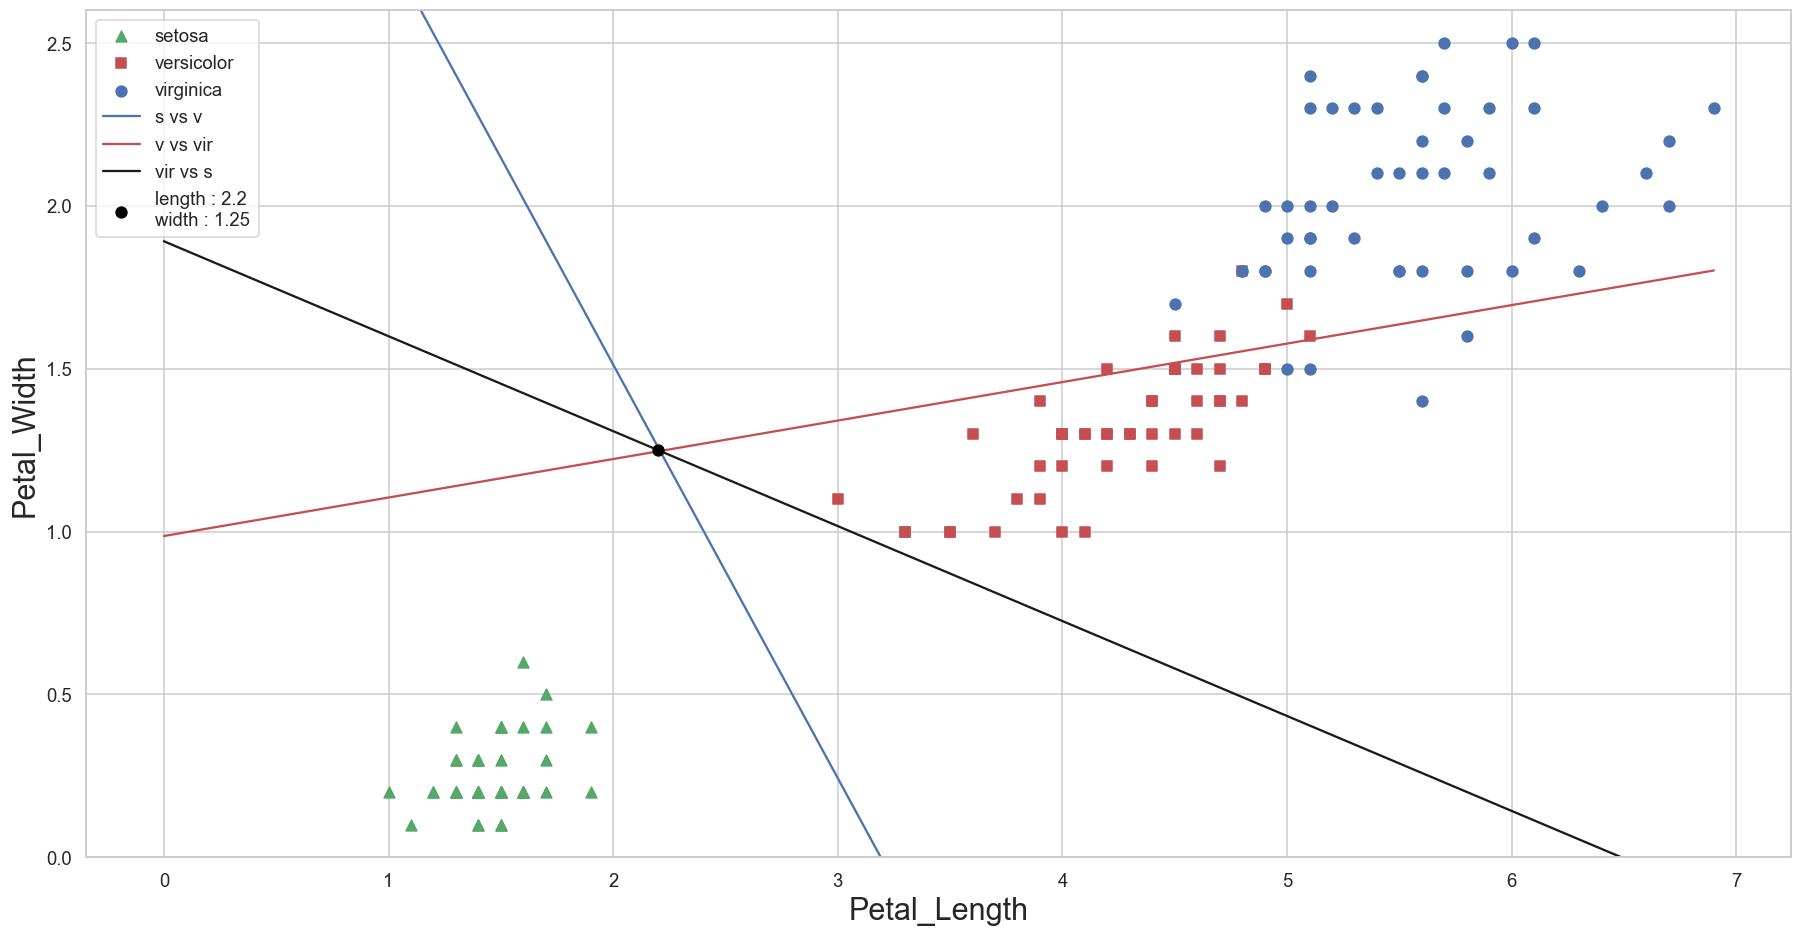

In [6]:

plt.scatter(x_petal_length[y==0] , x_petal_width[y==0] , marker = "^" ,
             color = "g" , label = "setosa"     ,s =50)

plt.scatter(x_petal_length[y==1] , x_petal_width[y==1] , marker = "s" ,
             color = "r" , label = "versicolor" ,s =50)

plt.scatter(x_petal_length[y==2] , x_petal_width[y==2] , marker = "o" ,
             color = "b" , label = "virginica"  ,s =50)

plt.legend( fontsize = 20 )

plt.xlabel("Petal_Length")

plt.ylabel("Petal_Width")

theta1 = theta[0] - theta[1]
theta2 = theta[1] - theta[2]
theta3 = theta[2] - theta[0]

x_plot_petal_length = np.linspace(0, x_petal_length.max() , 2000).reshape((-1,1))

x_plot_1 = -(theta1[1] * x_plot_petal_length + theta1[0]) / theta1[2]
x_plot_2 = -(theta2[1] * x_plot_petal_length + theta2[0]) / theta2[2]
x_plot_3 = -(theta3[1] * x_plot_petal_length + theta3[0]) / theta3[2]

plt.plot(x_plot_petal_length ,  x_plot_1 , "b" , label = "s vs v" )
plt.plot(x_plot_petal_length ,  x_plot_2 , "r", label  = "v vs vir" )
plt.plot(x_plot_petal_length ,  x_plot_3 , "k" , label = "vir vs s")

intersection_length = 2.2
intersection_width  = 1.25

plt.scatter(intersection_length ,  intersection_width , 
            label = f"length : {intersection_length} \nwidth : {intersection_width}" ,
              zorder = 50 , color = "black" ,s =50)
plt.ylim(0, 2.6)
plt.legend()
plt.show() 
 

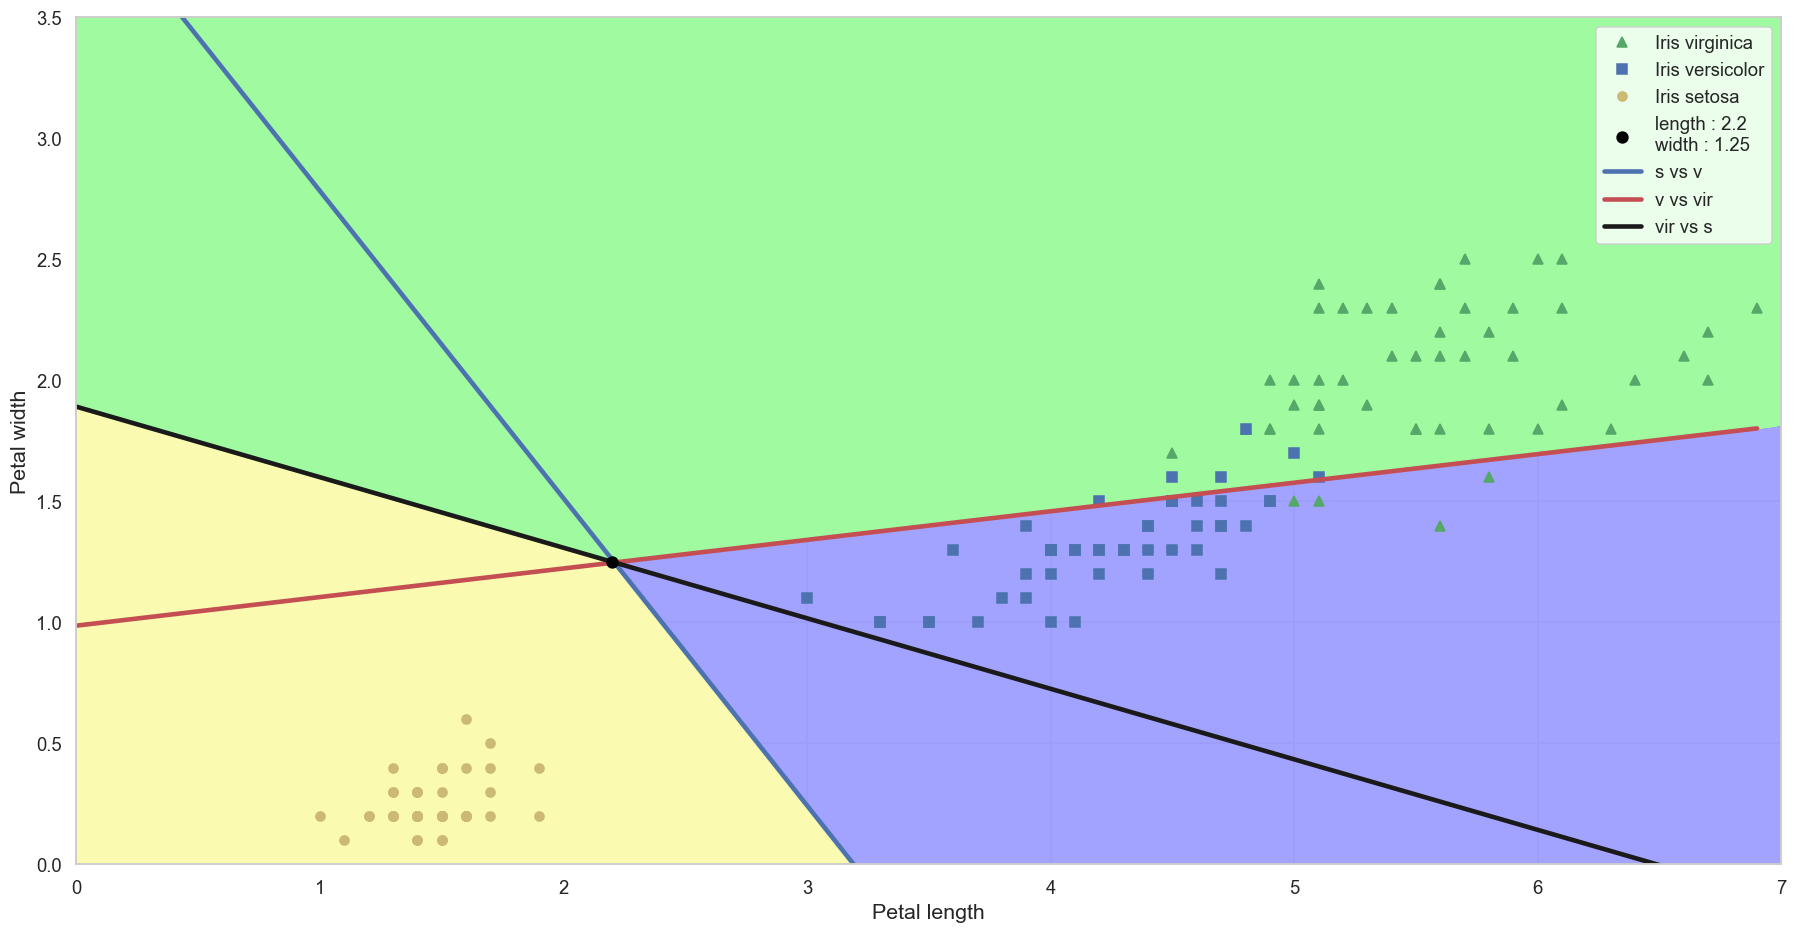

In [7]:

X , y = iris["data"][: , 2:] , iris["target"]
x0, x1 = np.meshgrid(
        np.linspace(0, 8, 1000).reshape(-1, 1),
        np.linspace(0, 3.5, 1000).reshape(-1, 1),
    )

X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = predict_proba(X_new,  theta)
y_predict = predict(X_new,  theta)

zz = y_predict.reshape(x0.shape)


plt.plot(X[y==2, 0], X[y==2, 1], "g^", label="Iris virginica")
plt.plot(X[y==1, 0], X[y==1, 1], "bs", label="Iris versicolor")
plt.plot(X[y==0, 0], X[y==0, 1], "yo", label="Iris setosa")

from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0',"#9898ffe6",'#a0faa0'])

intersection_length = 2.2
intersection_width = 1.25
plt.scatter(intersection_length ,  intersection_width , 
            label = f"length : {intersection_length} \nwidth : {intersection_width}" ,
              zorder = 50 , color = "black" ,s =50)


plt.contourf(x0, x1, zz, cmap=custom_cmap )
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0, 7, 0, 3.5])

theta1 = theta[0] - theta[1]
theta2 = theta[1] - theta[2]
theta3 = theta[2] - theta[0]

x_plot_petal_length = np.linspace(0, x_petal_length.max() , 2000).reshape((-1,1))

x_plot_1 = -(theta1[1] * x_plot_petal_length + theta1[0]) / theta1[2]
x_plot_2 = -(theta2[1] * x_plot_petal_length + theta2[0]) / theta2[2]
x_plot_3 = -(theta3[1] * x_plot_petal_length + theta3[0]) / theta3[2]

plt.plot(x_plot_petal_length ,  x_plot_1 , "b" , label = "s vs v"  , linewidth = 3 )
plt.plot(x_plot_petal_length ,  x_plot_2 , "r", label  = "v vs vir" , linewidth = 3 )
plt.plot(x_plot_petal_length ,  x_plot_3 , "k" , label = "vir vs s" , linewidth = 3)

plt.legend()
plt.show()
 